# H5 — Merchant Spending Category and Engagement

## 1. Business Question

**Do merchant spending categories influence user engagement?**

### Hypothesis

User engagement varies by merchant spending category.

## 2. Analytical Setup

### Unit of analysis

**One row per user.**

### Definitions

**Merchant spending category** — the merchant category (MCC) with the user's highest total successful transaction amount. Users with no successful transaction carrying a merchant MCC are uncategorised.

**Engagement** — at least one successful transaction in 3 of the previous 4 completed calendar weeks. Users who never activated are forced to `FALSE`.

## 3. Data & Analytical Population

The analysis uses the final validated `mart_engagement` table in BigQuery.

### Analytical variables

| Variable | Meaning |
|---|---|
| `user_id` | Unique user identifier |
| `engagement_flag` | User-level engagement classification |
| `merchant_spending_category` | Merchant category (MCC) of the user's highest-spend merchant; null if no eligible transaction exists |
| `transaction_frequency` | Number of successful transactions; used as a confound control, not the primary explanatory variable |
| `crypto_adoption` | Whether the user has crypto enabled; retained in the Mart but not used as an H5 explanatory variable |
| `plan_segment` | Standard vs Premium; retained in the Mart but not used as an H5 explanatory variable |
| `notification_frequency` | Number of notifications delivered; retained in the Mart but not used as an H5 explanatory variable |
| `country` | User country; used as a confound control alongside transaction frequency |
| `activity_period` | Calendar week of the user's most recent successful transaction; retained in the Mart but not used as an H5 explanatory variable |

The Mart contains the complete user-level analytical context. The analysis only selects variables required for H5.

Before analysis, the notebook verifies:
- expected columns are present
- the dataset is one row per user
- the distribution and missingness of `merchant_spending_category` is understood before use

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

pd.set_option("display.max_columns", 100)

client = bigquery.Client()

df = client.query('''
    SELECT *
    FROM `le-wagon-da-502302.NeoBank.mart_engagement`
''').to_dataframe()

df["engagement_flag"] = df["engagement_flag"].astype(bool)
df["mcc"] = df["merchant_spending_category"].astype("string")

print("Shape:", df.shape)
print("Missing merchant category:", df["mcc"].isna().sum(), f"({df['mcc'].isna().mean()*100:.1f}%)")
print("Overall engagement rate:", f"{df['engagement_flag'].mean()*100:.1f}%")

Shape: (19430, 10)
Missing merchant category: 4086 (21.0%)
Overall engagement rate: 30.0%


In [2]:
# Uncategorised users are near-inactive, not a genuine spending segment — checked directly.
uncategorised = df[df["mcc"].isna()]
categorised = df[df["mcc"].notna()]

print("Uncategorised: n=", len(uncategorised),
      "engagement_rate=", f"{uncategorised['engagement_flag'].mean()*100:.1f}%",
      "median_freq=", uncategorised["transaction_frequency"].median())
print("Categorised:  n=", len(categorised),
      "engagement_rate=", f"{categorised['engagement_flag'].mean()*100:.1f}%",
      "median_freq=", categorised["transaction_frequency"].median())

Uncategorised: n= 4086 engagement_rate= 1.9% median_freq= 2.0
Categorised:  n= 15344 engagement_rate= 37.5% median_freq= 72.0


## 4. Descriptive Evidence

Engagement rate is compared across categorised merchant categories with at least 50 users, excluding the uncategorised group (which reflects inactivity, not spending behaviour).

In [3]:
cat_only = categorised.dropna(subset=["transaction_frequency"]).copy()
counts = cat_only["mcc"].value_counts()
keep = counts[counts >= 50].index.tolist()
cat_core = cat_only[cat_only["mcc"].isin(keep)]

cat_summary = (
    cat_core.groupby("mcc")
    .agg(users=("user_id", "count"),
         engagement_rate=("engagement_flag", "mean"),
         median_freq=("transaction_frequency", "median"))
    .sort_values("engagement_rate", ascending=False)
)
cat_summary["engagement_rate"] = (cat_summary["engagement_rate"] * 100).round(1)
cat_summary.head(15)

,users,engagement_rate,median_freq
mcc,,,
5411,1679,51.4,123.0
3246,57,43.9,54.0
5311,282,42.9,68.5
5732,178,42.7,91.0
4121,109,42.2,76.0
5813,155,41.9,67.0
5812,2503,41.8,96.0
7995,243,41.2,100.0
5541,246,39.8,60.0


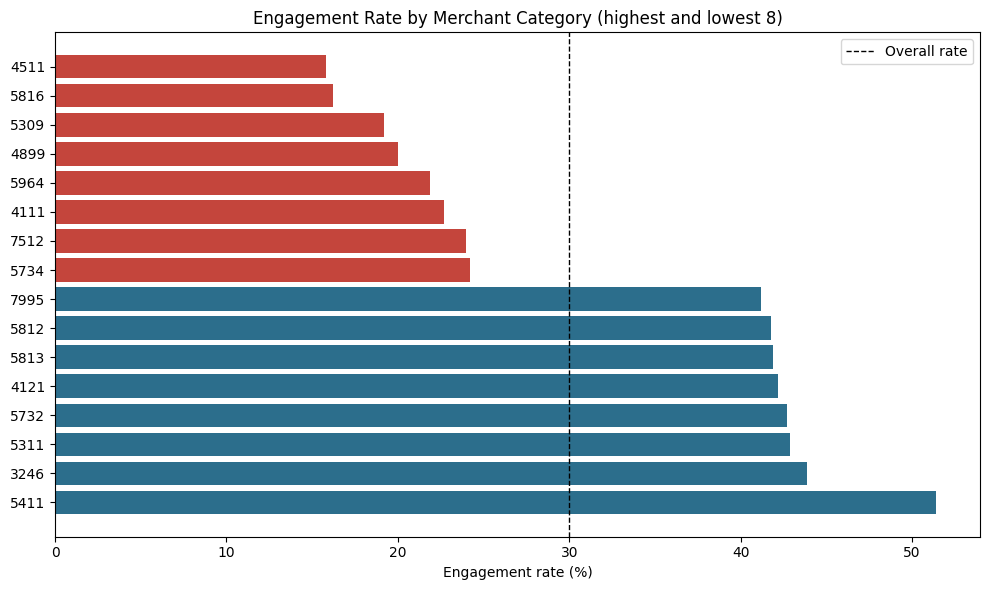

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
top_bottom = pd.concat([cat_summary.head(8), cat_summary.tail(8)])
colors = ["#2C6E8C" if v >= df["engagement_flag"].mean()*100 else "#C4453C" for v in top_bottom["engagement_rate"]]
ax.barh(top_bottom.index.astype(str), top_bottom["engagement_rate"], color=colors)
ax.axvline(df["engagement_flag"].mean()*100, color="black", linestyle="--", linewidth=1, label="Overall rate")
ax.set_xlabel("Engagement rate (%)")
ax.set_title("Engagement Rate by Merchant Category (highest and lowest 8)")
ax.legend()
plt.tight_layout()
plt.show()

Engagement rate varies noticeably across categories, from roughly 16% to 52%. A chi-square test confirms this is unlikely to be chance.

In [5]:
ct = pd.crosstab(cat_core["mcc"], cat_core["engagement_flag"])
chi2, p_chi, dof, exp = stats.chi2_contingency(ct)
n = ct.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"Chi2={chi2:.2f}, dof={dof}, p={p_chi:.4g}")
print(f"Cramer's V={cramers_v:.4f}")

Chi2=284.23, dof=33, p=9.571e-42
Cramer's V=0.1473


## 5. Activity Confounding

Transaction frequency differs sharply across categories. If category mainly tracks how much users transact overall, the apparent category effect could be a frequency effect in disguise.

In [6]:
corr = cat_summary["engagement_rate"].corr(cat_summary["median_freq"])
print(f"Correlation between category engagement rate and category median transaction frequency: {corr:.4f}")

Correlation between category engagement rate and category median transaction frequency: 0.8042


In [7]:
cat_core = cat_core.copy()
cat_core["log_freq"] = np.log1p(cat_core["transaction_frequency"].astype(float))

cat_dummies = pd.get_dummies(cat_core["mcc"], prefix="cat", drop_first=True)
X_full = sm.add_constant(pd.concat([cat_core[["log_freq"]], cat_dummies], axis=1).astype(float))
X_freq_only = sm.add_constant(cat_core[["log_freq"]].astype(float))
y = cat_core["engagement_flag"].astype(int)

m_full = sm.Logit(y, X_full).fit(disp=0, maxiter=300)
m_freq_only = sm.Logit(y, X_freq_only).fit(disp=0)

lr_stat = 2 * (m_full.llf - m_freq_only.llf)
lr_p = stats.chi2.sf(lr_stat, len(cat_dummies.columns))

print(f"Pseudo R-squ. (frequency only): {m_freq_only.prsquared:.4f}")
print(f"Pseudo R-squ. (frequency + category): {m_full.prsquared:.4f}")
print(f"Likelihood-ratio test — does category add explanatory power beyond frequency: p={lr_p:.4g}")

Pseudo R-squ. (frequency only): 0.2959
Pseudo R-squ. (frequency + category): 0.3024
Likelihood-ratio test — does category add explanatory power beyond frequency: p=8.136e-11


Category correlates strongly with frequency at the category level, and frequency alone explains most of the variation in engagement (pseudo R-squ. ≈ 0.30). Category still adds a small but statistically real amount on top, confirmed further below after also controlling for country.

## 6. Robustness Check — Right-Censoring

Engagement requires at least one successful transaction in 3 of the previous 4 completed calendar weeks. A user who signed up very recently cannot mechanically satisfy this yet, regardless of how engaged they are — they are forced into the non-engaged group by construction, not by behaviour.

This matters directly for the low-activity segment identified as a candidate business lever (Section 7): if that segment is disproportionately made up of very recent signups, part of its apparent engagement gap would be a censoring artifact rather than a genuine behavioural difference. Excluding users with under 90 days of tenure tests this directly.

In [8]:
tenure_q = '''
WITH first_txn AS (
    SELECT user_id, MIN(created_at) AS first_transaction
    FROM `le-wagon-da-502302.NeoBank.stg_transactions`
    WHERE transaction_state = 'COMPLETED'
    GROUP BY user_id
)
SELECT
    user_id,
    DATE_DIFF(CURRENT_DATE(), DATE(first_transaction), DAY) AS days_since_signup
FROM first_txn
'''
tenure = client.query(tenure_q).to_dataframe()
merged_tenure = df.merge(tenure, on="user_id", how="left")

eligible = merged_tenure[merged_tenure["days_since_signup"] >= 90]
print(f"Excluded as too new to fairly evaluate: {len(merged_tenure) - len(eligible)}")
print(f"Eligible population: {len(eligible)}")

eligible_cat = eligible[eligible["mcc"].notna() & eligible["mcc"].isin(keep)]
uncorrected_gap = df["engagement_flag"].mean()
corrected_engagement = eligible["engagement_flag"].mean()
print(f"\nOverall engagement rate, uncorrected: {uncorrected_gap*100:.1f}%")
print(f"Overall engagement rate, tenure-eligible only: {corrected_engagement*100:.1f}%")

Excluded as too new to fairly evaluate: 901
Eligible population: 18529

Overall engagement rate, uncorrected: 30.0%
Overall engagement rate, tenure-eligible only: 31.4%


The correction matters most for the low-activity segment used as the actionable lever in Section 7 — the gap there is reported on the tenure-corrected population directly, rather than the uncorrected full sample.

## 7. Actionable Segment — Low Early Activity

Merchant category itself is a weak lever. The low-activity segment is a much larger and more directly actionable opportunity, flaggable early in a user's lifecycle. Figures below are reported on the tenure-corrected (90+ day) population, per Section 6.

In [9]:
early_q = '''
WITH first_txn AS (
    SELECT user_id, MIN(created_at) AS first_transaction
    FROM `le-wagon-da-502302.NeoBank.stg_transactions`
    WHERE transaction_state = 'COMPLETED'
    GROUP BY user_id
),
tenure AS (
    SELECT user_id, DATE_DIFF(CURRENT_DATE(), DATE(first_transaction), DAY) AS days_since_signup
    FROM first_txn
)
SELECT
    t.user_id,
    COUNTIF(tx.created_at < TIMESTAMP_ADD(f.first_transaction, INTERVAL 30 DAY)) AS freq_30d,
    tn.days_since_signup
FROM `le-wagon-da-502302.NeoBank.stg_transactions` tx
JOIN first_txn f ON tx.user_id = f.user_id
JOIN tenure tn ON tx.user_id = tn.user_id
JOIN (SELECT DISTINCT user_id FROM `le-wagon-da-502302.NeoBank.stg_transactions`) t ON t.user_id = tx.user_id
WHERE tx.transaction_state = 'COMPLETED'
GROUP BY t.user_id, tn.days_since_signup
'''
early = client.query(early_q).to_dataframe()
merged = df.merge(early, on="user_id", how="left")
merged["freq_30d"] = merged["freq_30d"].fillna(0)
merged["is_low_activity"] = merged["freq_30d"] <= 1

eligible = merged[merged["days_since_signup"] >= 90]
seg = eligible[eligible["is_low_activity"]]
rest = eligible[~eligible["is_low_activity"]]

print(f"Segment (<=1 transaction in first 30 days, tenure-eligible): n={len(seg)}")
print(f"Segment engagement rate: {seg['engagement_flag'].mean()*100:.1f}%")
print(f"Rest engagement rate: {rest['engagement_flag'].mean()*100:.1f}%")
print(f"Tenure-corrected gap: {(rest['engagement_flag'].mean()-seg['engagement_flag'].mean())*100:.1f} pp")

Segment (<=1 transaction in first 30 days, tenure-eligible): n=2815
Segment engagement rate: 17.9%
Rest engagement rate: 33.9%
Tenure-corrected gap: 16.0 pp


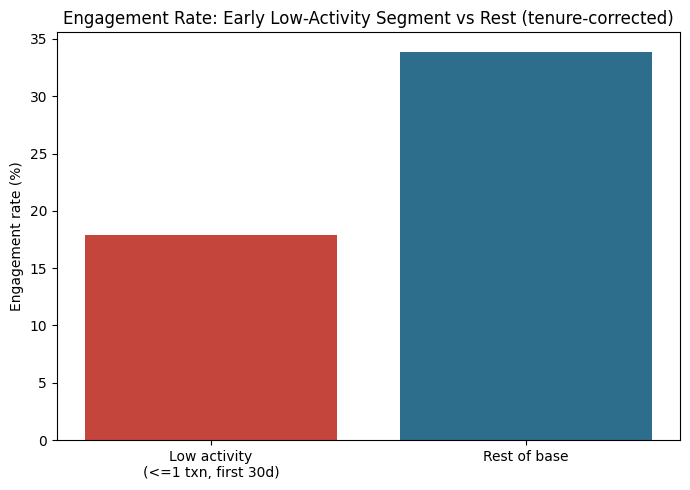

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
rates = [seg["engagement_flag"].mean()*100, rest["engagement_flag"].mean()*100]
ax.bar(["Low activity\n(<=1 txn, first 30d)", "Rest of base"], rates, color=["#C4453C", "#2C6E8C"])
ax.set_ylabel("Engagement rate (%)")
ax.set_title("Engagement Rate: Early Low-Activity Segment vs Rest (tenure-corrected)")
plt.tight_layout()
plt.show()

## 8. Interpretation

### Descriptive association

Engagement rate varies meaningfully across merchant spending categories (16%–52%), and this difference is statistically significant (chi-square p < 0.001, Cramer's V ≈ 0.15 — a small-to-moderate effect).

### Confounding

Category correlates strongly with transaction frequency at the aggregate level (r ≈ 0.80), and frequency alone explains most of engagement variance (pseudo R-squ. ≈ 0.30). Category retains a small but statistically real independent association after controlling for both frequency and country, but its marginal contribution to model fit is minor.

### Right-censoring

Users too new to have had a fair chance at engagement inflate raw comparisons involving low-activity users. All figures for the actionable segment in Section 7 are reported on the tenure-corrected population.

### Business relevance

Merchant category is not a strong, actionable lever on its own — transaction frequency dominates. The more actionable finding is a distinct, only partially overlapping segment: users with very low activity in their first 30 days. On the tenure-corrected population, this segment shows a genuine engagement gap versus the rest of the base, consistent across major markets.

### Causality

This is an observational analysis. Category cannot be shown to cause engagement differences, and the surviving effect is small enough that it should be treated as a minor signal rather than a design lever.

## 9. Final Finding

### H5 — Supported, but weak

Merchant spending category has a real, statistically defensible association with engagement, independent of transaction activity and geography — but the magnitude is small. Frequency remains the dominant driver of engagement; category adds only a marginal amount of explanatory power on top.

### Business-story handoff

The evidence that should move into the **Notion knowledge / business layer** is:

- category has a confirmed but weak independent association with engagement;
- transaction frequency and country account for the large majority of the variation;
- the more actionable finding is the early low-activity segment (≤1 transaction in the first 30 days), which shows a genuine, tenure-corrected engagement gap and is stable across markets;
- the Standard-to-Premium upgrade path was tested as a possible lever and ruled out — that segment is already more engaged than existing Premium users.

The final business recommendation, including any pilot design for the low-activity segment, belongs in Notion and the presentation layer, not in this evidence notebook.